In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('jobSalary.csv')


print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (15280, 10)
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications    salary  
0     Healthcare       Medium      India      Hybrid             2.0  109413.0  
1        Telecom        Small  Australia          No             0.0   93764.0  
2          Media       Medium  Singapore          No             1.0  148123.0  
3         Retail       Medium     Canada         Yes             0.0  189123.0  
4  Manufacturing        Large     Sweden         Yes             0.0  165069.0  


In [2]:
# Initial Inspection
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15280 entries, 0 to 15279
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         15280 non-null  object 
 1   experience_years  15280 non-null  int64  
 2   education_level   15280 non-null  object 
 3   skills_count      15280 non-null  int64  
 4   industry          15279 non-null  object 
 5   company_size      15279 non-null  object 
 6   location          15279 non-null  object 
 7   remote_work       15279 non-null  object 
 8   certifications    15279 non-null  float64
 9   salary            15279 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 1.2+ MB
None
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18  

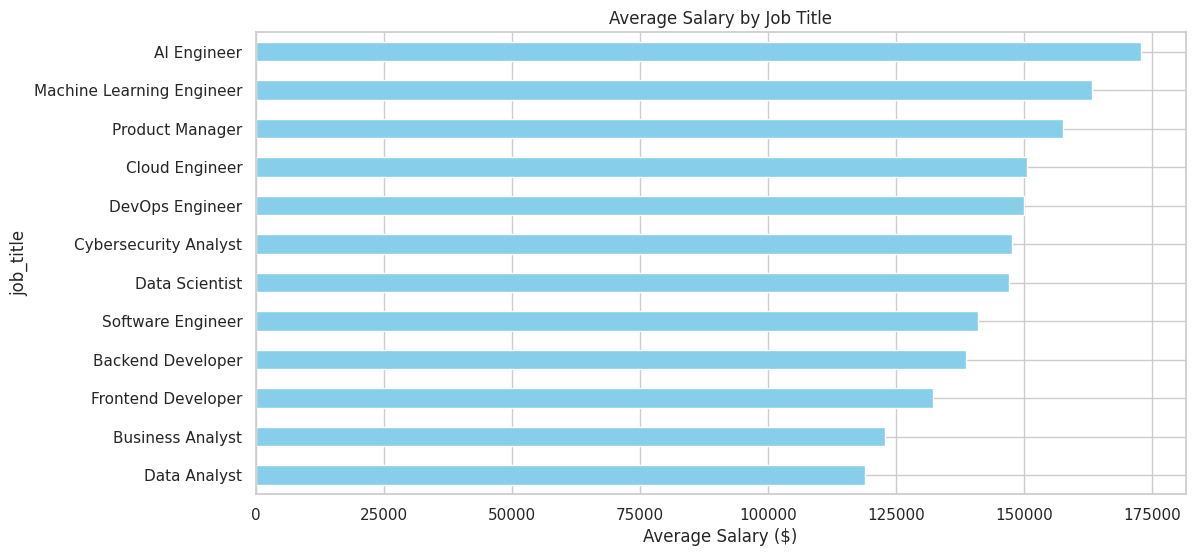

/tmp/ipykernel_5269/947798010.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='education_level', y='salary', palette='Set2', order=edu_order)


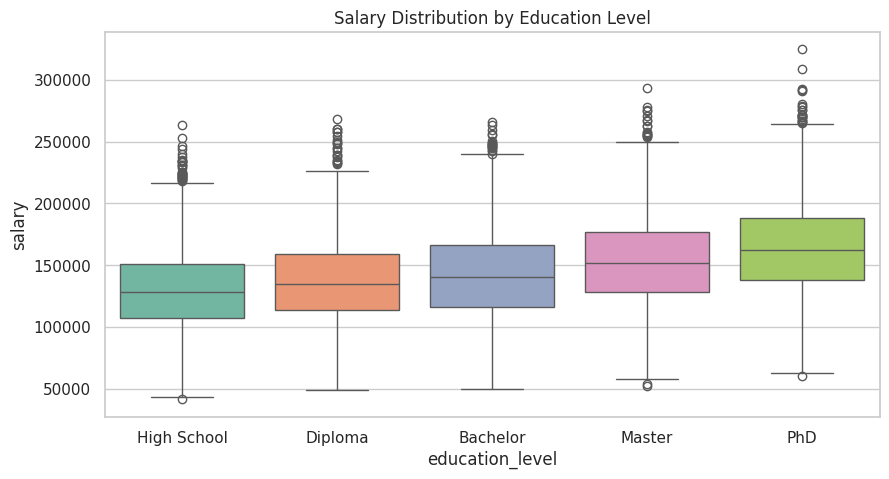

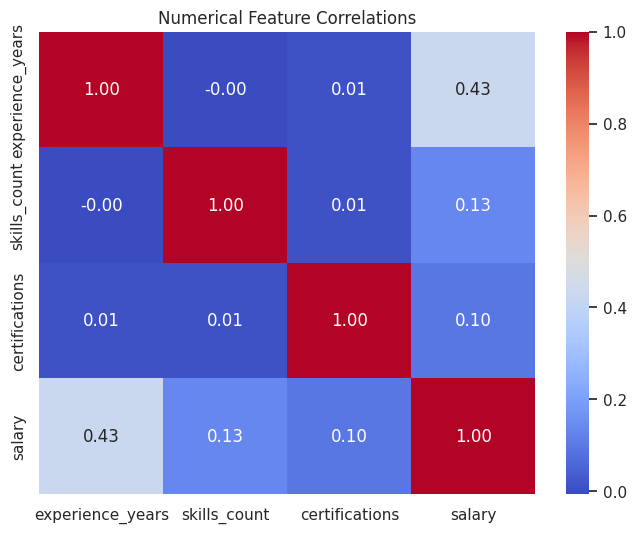

In [3]:
# Set visualization style
sns.set_theme(style="whitegrid")

#Average Salary by Job Title
plt.figure(figsize=(12, 6))
df.groupby('job_title')['salary'].mean().sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Salary by Job Title')
plt.xlabel('Average Salary ($)')
plt.show()

#Salary by Education Level (Boxplot)
plt.figure(figsize=(10, 5))
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
sns.boxplot(data=df, x='education_level', y='salary', palette='Set2', order=edu_order)
plt.title('Salary Distribution by Education Level')
plt.show()

#Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlations')
plt.show()

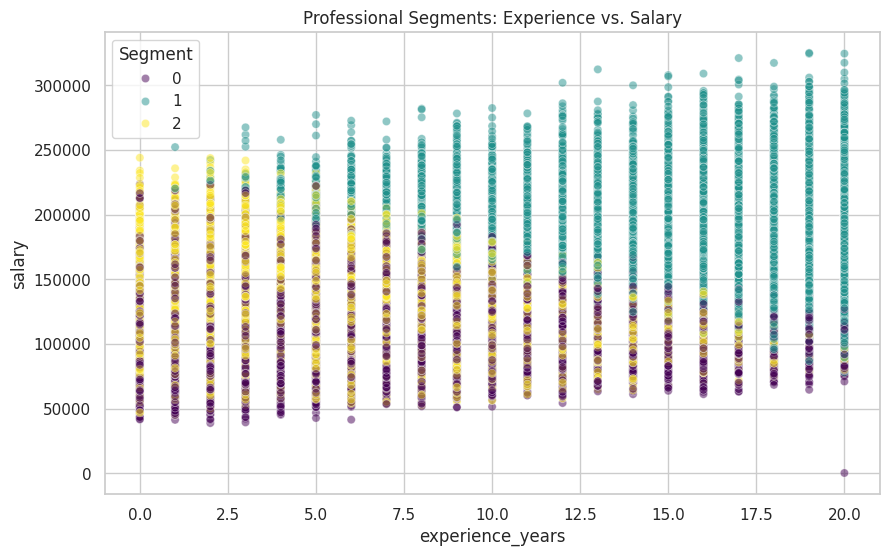

In [ ]:
# Select features for clustering
segment_data = df[['experience_years', 'skills_count', 'salary']]

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segment_data)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(scaled_features)

# Visualize the resulting segments
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='experience_years', y='salary', hue='Segment', palette='viridis', alpha=0.5)
plt.title('Professional Segments: Experience vs. Salary')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df_model = df.copy()
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])


X = df_model.drop(columns=['salary', 'segment_label'], errors='ignore')
y = df_model['salary']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)



# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n--- Linear Regression Metrics ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_lr):.4f}")

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=50, random_state=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest Metrics ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_rf):.4f}")


--- Linear Regression Metrics ---
MAE: 21913.33
R^2 Score: 0.4533

--- Random Forest Metrics ---
MAE: 5803.62
R^2 Score: 0.9611


In [4]:
import pandas as pd
import matplotlib.pyplot as plt


features = [
    'job_title', 'experience_years', 'education_level', 'skills_count',
    'industry', 'company_size', 'location', 'certifications'
]


plt.figure(figsize=(10, 6))


feat_importances = pd.Series(rf_model.feature_importances_, index=features)


feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Most Important Factors Influencing Salary')
plt.xlabel('Importance Score')
plt.ylabel('Factors')
plt.tight_layout()
plt.show()



NameError: name 'rf_model' is not defined

<Figure size 1000x600 with 0 Axes>

In [5]:

df.to_csv('job_salary_processed.csv', index=False)

print("Segmentation complete! Your clean CSV is ready for Power BI.")


Segmentation complete! Your clean CSV is ready for Power BI.
